# RSL Reproducibility Notebook — YOLO-Multispectral (Transfer Learning vs Scratch)

This notebook reproduces the controlled experiments reported in the RSL manuscript:

**Maintaining Transfer Learning in YOLOv11 for 4+-Band Multispectral Remote-Sensing Detection and Segmentation**.

It runs the official experiment runner from the repository release tag:

- **Release:** `rsl-transfer-learning-v1.0`  
- **Repo:** https://github.com/aesparon/YOLO-Multispectral  
- **Release URL:** https://github.com/aesparon/YOLO-Multispectral/releases/tag/rsl-transfer-learning-v1.0

## What this notebook does
- Clones the repository at the paper release tag
- Installs dependencies
- Verifies dataset paths
- Runs **one** controlled experiment using the same code path as the batch script:
  - **Transfer learning** (`init_type="pt"`) **or**
  - **Training from scratch** (`init_type="yaml"`)
- Uses **seed = 0**, **channel_init_mode = "avg"**, and **no architectural extensions**


### Step 1) Setup (clone repo + install dependencies)


In [2]:

#  Clone repository and install requirements.txt
import os

current_path = os.getcwd()
clone_dir = current_path + "/YOLO-Multispectral"
# Update if exists
if os.path.isdir(clone_dir):
    print(f"Repo already exists: {clone_dir}")

else:
    # Clone your GitHub repo
    print(f"Clone repo to : {clone_dir}")
    !git clone https://github.com/aesparon/YOLO-Multispectral.git
    # Change directory to the repo root   REMOVE FOR COLAB
    #%cd YOLO-Multispectral

# Now install requirements
req_path = os.path.join(clone_dir, "code", "requirements.txt")
!pip install -r "{req_path}"


Repo already exists: d:\PD\Publications\Yolo_mod\github\YOLO-Multispectral_2026_01_29\test_notebook_v2_restore/YOLO-Multispectral
Defaulting to user installation because normal site-packages is not writeable


The system cannot find the path specified.


### Step 2. Download weeds galore dataset


In [3]:
# add code path for script files
import os
import sys 

# add code folder
code_path = os.path.abspath(clone_dir +  "/code/")
sys.path.insert(0, code_path)
from utils_downloader import download_and_extract_zip

# modified yolo source for multispectral
#yolo_source_path=os.path.abspath(clone_dir +  "/code/ultralytics_MS/")

# Set parameters
url = "https://doidata.gfz.de/weedsgalore_e_celikkan_2024/weedsgalore-dataset.zip"
output_zip = clone_dir + "/datasets/weedsgalore-dataset.zip"
extract_dir = clone_dir + "/datasets/"

# Call the function
download_and_extract_zip(url, output_zip, extract_dir)

🔍 Checking file info...
📥 Downloading with resume support...


Downloading: 100%|██████████| 321M/321M [00:57<00:00, 5.89MB/s] 


✅ Download complete: d:\PD\Publications\Yolo_mod\github\YOLO-Multispectral_2026_01_29\test_notebook_v2_restore/YOLO-Multispectral/datasets/weedsgalore-dataset.zip
📦 Extracting...


Extracting: 100%|██████████| 1119/1119 [00:01<00:00, 795.70file/s]

✅ Extracted to: d:\PD\Publications\Yolo_mod\github\YOLO-Multispectral_2026_01_29\test_notebook_v2_restore/YOLO-Multispectral/datasets/


### 🔍 Step 3: Create train/val/test for RGB and RGBRN
##### Downloaded data set needs to be pre-processed. Stacked and sorted into train/val/test


In [4]:
from pre_process_images import *    # for main_process_RGB_RGBRN and helper functions


# uint8 required for yolo images, uint16 fails training  - check later - best method
# Stack RGB and RGBRN images and convert from uint16 to uint8 and split train/val/test  #######################################################3
#  yolo does not train on uint16 but will mod yolo to test any increase in accuracy using uinr16 over uint8 (future wotk)

classes_list = ['maize','amaranth','grass','quickweed','other']
uint16_to_uint8_method = 'normalize'   # 'stretch'    # 'normalize' 

# return train pathe  to view sample images
images_train_path_RGB = main_process_RGB_RGBRN(clone_dir, classes_list ,extract_dir,uint16_to_uint8_method)



✅ Copied: 2023-05-25_0109_B.png
✅ Copied: 2023-05-25_0109_G.png
✅ Copied: 2023-05-25_0109_NIR.png
✅ Copied: 2023-05-25_0109_R.png
✅ Copied: 2023-05-25_0109_RE.png
✅ Copied: 2023-05-25_0114_B.png
✅ Copied: 2023-05-25_0114_G.png
✅ Copied: 2023-05-25_0114_NIR.png
✅ Copied: 2023-05-25_0114_R.png
✅ Copied: 2023-05-25_0114_RE.png
✅ Copied: 2023-05-25_0119_B.png
✅ Copied: 2023-05-25_0119_G.png
✅ Copied: 2023-05-25_0119_NIR.png
✅ Copied: 2023-05-25_0119_R.png
✅ Copied: 2023-05-25_0119_RE.png
✅ Copied: 2023-05-25_0147_B.png
✅ Copied: 2023-05-25_0147_G.png
✅ Copied: 2023-05-25_0147_NIR.png
✅ Copied: 2023-05-25_0147_R.png
✅ Copied: 2023-05-25_0147_RE.png
✅ Copied: 2023-05-25_0150_B.png
✅ Copied: 2023-05-25_0150_G.png
✅ Copied: 2023-05-25_0150_NIR.png
✅ Copied: 2023-05-25_0150_R.png
✅ Copied: 2023-05-25_0150_RE.png
✅ Copied: 2023-05-25_0158_B.png
✅ Copied: 2023-05-25_0158_G.png
✅ Copied: 2023-05-25_0158_NIR.png
✅ Copied: 2023-05-25_0158_R.png
✅ Copied: 2023-05-25_0158_RE.png
✅ Copied: 2023-05-25_0

C:\Users\andre\AppData\Roaming\Python\Python311\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
C:\Users\andre\AppData\Roaming\Python\Python311\site-packages\rasterio\__init__.py:378: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


✅ Saved: d:\PD\Publications\Yolo_mod\github\YOLO-Multispectral_2026_01_29\test_notebook_v2_restore/YOLO-Multispectral/datasets/weeds_galore_processed/RGB//RGB_uint16/2023-05-25_0109.tif
✅ Saved: d:\PD\Publications\Yolo_mod\github\YOLO-Multispectral_2026_01_29\test_notebook_v2_restore/YOLO-Multispectral/datasets/weeds_galore_processed/RGB//RGB_uint16/2023-05-25_0114.tif
✅ Saved: d:\PD\Publications\Yolo_mod\github\YOLO-Multispectral_2026_01_29\test_notebook_v2_restore/YOLO-Multispectral/datasets/weeds_galore_processed/RGB//RGB_uint16/2023-05-25_0119.tif
✅ Saved: d:\PD\Publications\Yolo_mod\github\YOLO-Multispectral_2026_01_29\test_notebook_v2_restore/YOLO-Multispectral/datasets/weeds_galore_processed/RGB//RGB_uint16/2023-05-25_0147.tif
✅ Saved: d:\PD\Publications\Yolo_mod\github\YOLO-Multispectral_2026_01_29\test_notebook_v2_restore/YOLO-Multispectral/datasets/weeds_galore_processed/RGB//RGB_uint16/2023-05-25_0150.tif
✅ Saved: d:\PD\Publications\Yolo_mod\github\YOLO-Multispectral_2026_01

### Visualise annotations


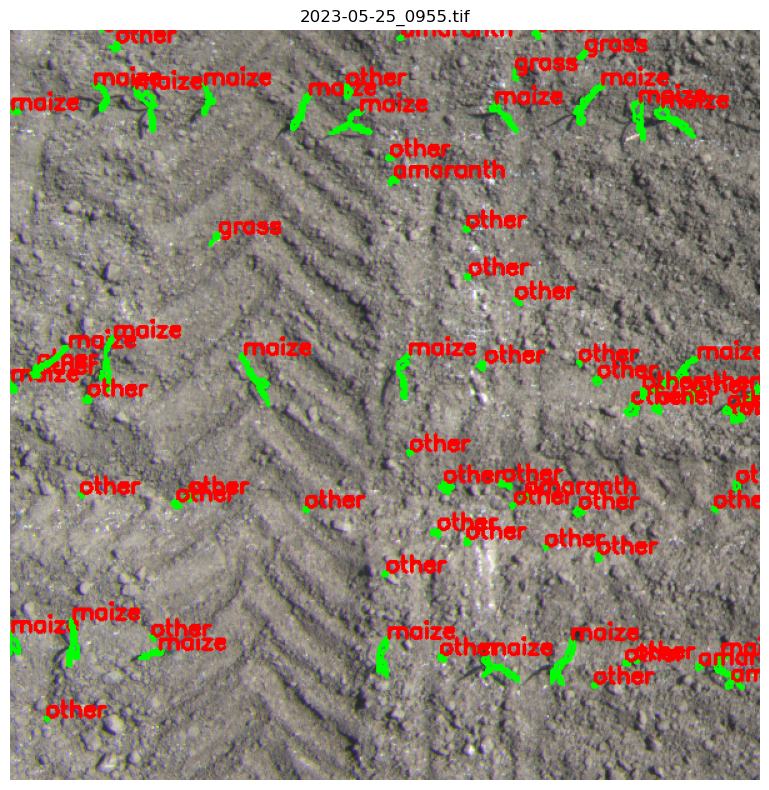

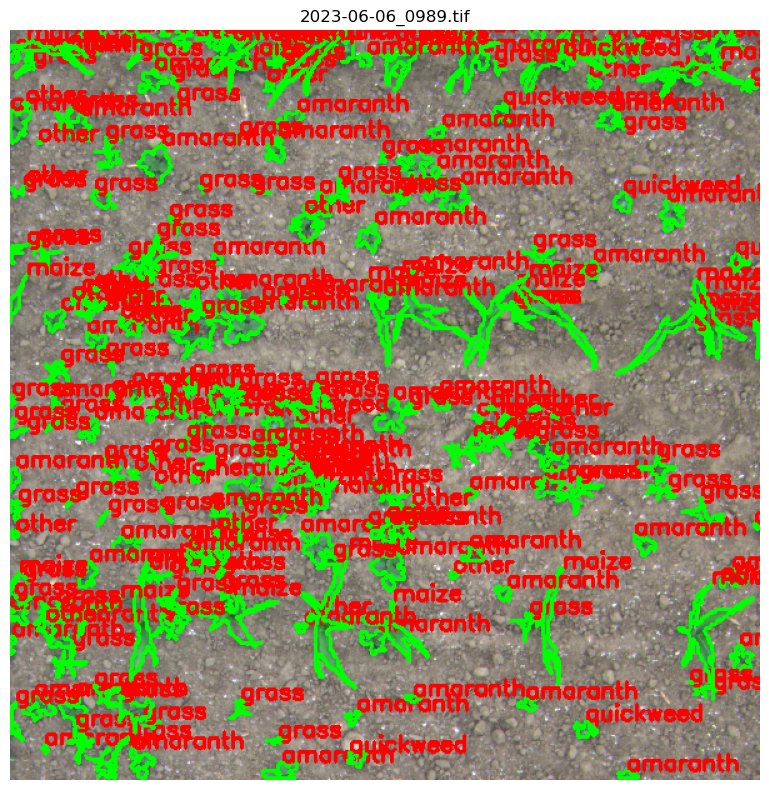

In [5]:
import importlib
import visualise_yolo_annotations

importlib.reload(visualise_yolo_annotations)
from visualise_yolo_annotations import plot_yolo_segmentation
%matplotlib inline

# RANDOM SELECTION
number_of_samples_to_view = 2
plot_yolo_segmentation(images_train_path_RGB + '/images/', images_train_path_RGB + '/labels/', class_names=classes_list, num_samples=number_of_samples_to_view)

### Step 4. Set parameters to modify YOLO and create multispectral model.

In [6]:
import sys
from pathlib import Path
import torch

repo_root = Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

try:
    import ultralytics
    print("Ultralytics:", ultralytics.__version__)
except Exception as e:
    print("Ultralytics import warning:", e)

import run_transfer_vs_scratch_extended as ext

Ultralytics import warning: No module named 'ultralytics'


In [7]:
# Note no additional attention modules added for replicating experimental results
# Refer paper
# Maintaining Transfer Learning in YOLOv11 for 4+-Band Multispectral Remote-Sensing Detection and Segmentation

import sys
from pathlib import Path
import torch

repo_root = Path(clone_dir) / "code" / "YOLO-Multispectral"
sys.path.insert(0, str(repo_root))

import run_transfer_vs_scratch_extended as ext


# Specify experiment to run   #################################################################################
rgb3_rgb5 = 'rgb3'      # 'rgb3'  or 'rgb5' 
init_type = "pt"        #  "pt" ( transfer learning )  or yaml  (from scratch, no TL)
seed=0                  #  current experiments cover seed = [0,1,2,3,4,5]

# results saved to   #  TODO  - create folder "exp_results" in same folder as notebook and store all experimental resuls there 
#  rgb3_extended__pt__avg__seed0
#  rgb3_extended__yaml__avg__seed0
#  rgb5_extended__pt__avg__seed0
#  rgb5_extended__yaml__avg__seed0
# etc
force_rerun = True    # if false and already run then skip running again



#  DO NOT CHANGE IF REPRODUCING EXPERIMENTAL RESULTS ##########################################################
######  Fixed across all experiments for reproducability and matching across rgb3 and rgb5  ######################
if rgb3_rgb5 == 'rgb3' :
    cfg = ext.EXPS[0]  # rgb3_extended (use ext.EXPS[0] for rgb3)
elif rgb3_rgb5 == 'rgb5' :
    cfg = ext.EXPS[1]  # rgb5_extended (use ext.EXPS[1] for rgb5)
else:
    print('error: config does not exist')


toggles = ext.ToggleConfig(
    use_cbam=False, use_eca=False, use_spectral=False,
    use_dropblock=False, drop_prob=0.10,
    use_groupnorm=False, gn_groups=4,
    use_wavelet_residual=False, wavelet_inject_stage=1, wavelet_alpha_init=0.0
)

train_cfg = ext.TrainConfig(
    epochs=600,
    imgsz=600,      # native size (YOLO pads to 608)
    batch=8,
    workers=0,      # notebook-safe
    patience=100,
    device="cuda" if torch.cuda.is_available() else "cpu",
    deterministic=True,
    optimizer="AdamW",
    lr0=0.001111,
    momentum=0.9,
    weight_decay=0.0005,
)




#   Run experiment  ##########################################################################################
result = ext.run_one(
    cfg=cfg,
    init_type=init_type,            # "pt" for TL, "yaml" for scratch
    channel_init_mode="avg",        # "avg" used as base for all experiments - other options to explore later 
    seed=seed,
    toggles=toggles,
    train_cfg=train_cfg,
    skip_if_done=True,              # skip if results.csv create for this experiment
    force_rerun=force_rerun,
)
print(result)



📦 Loading YOLO checkpoint (.pt): D:\PD\Publications\Yolo_mod\github\YOLO-Multispectral_2026_01_29\test_notebook_v2_restore\YOLO-Multispectral\code\yolo11x-seg.pt


100%|██████████| 119M/119M [00:11<00:00, 10.6MB/s] 


💾 Saving patched model -> D:\PD\Publications\Yolo_mod\github\YOLO-Multispectral_2026_01_29\test_notebook_v2_restore\YOLO-Multispectral\code\runs_transfer_vs_scratch_EXTENDED\rgb3_extended__pt__avg__seed0\mod_model_extended\yolo11x-seg_EXT_cbam0_eca0_spec0_db0_gn0_wnnS0.pt
🧾 Wrote metadata -> D:\PD\Publications\Yolo_mod\github\YOLO-Multispectral_2026_01_29\test_notebook_v2_restore\YOLO-Multispectral\code\runs_transfer_vs_scratch_EXTENDED\rgb3_extended__pt__avg__seed0\mod_model_extended\yolo11x-seg_EXT_cbam0_eca0_spec0_db0_gn0_wnnS0.meta.json

=== TRAIN rgb3_extended__pt__avg__seed0 ===
{'exp_id': 'rgb3_extended', 'dataset_id': 'rgb3', 'dataset_yaml': 'D:\\PD\\Publications\\Yolo_mod\\github\\YOLO-Multispectral_2026_01_29\\test_notebook_v2_restore\\YOLO-Multispectral\\datasets\\weeds_galore_processed\\RGB\\outputs\\data_RGB.yaml', 'in_channels': 3, 'seed': 0, 'init_type': 'pt', 'requested_channel_init_mode': 'avg', 'effective_init_mode': 'na', 'base_model': 'D:\\PD\\Publications\\Yolo_mod

100%|██████████| 5.35M/5.35M [00:00<00:00, 7.25MB/s]


fuse() called  skipping Conv+BN fusion (WNN/multispectral fork).
AMP: checks passed 
WARNING imgsz=[600] must be multiple of max stride 32, updating to [608]
train: Fast image access  (ping: 0.10.0 ms, read: 150.736.9 MB/s, size: 1197.2 KB)


...

     34/600      14.6G      1.432       2.28     0.9251       1.06        810        608: 100%|██████████| 13/13 [00:06<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  2.22it/s]

                   all         26       2376       0.56      0.465      0.483      0.277      0.499      0.425      0.439      0.177



      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  Instances       Size


     35/600      14.8G      1.467      2.264      0.925      1.053        556        608:  46%|████▌     | 6/13 [00:03<00:03,  1.86it/s]


KeyboardInterrupt: 

## 6) Summarize results for experiments run (read results.csv)


In [ ]:
import pandas as pd
from pathlib import Path

run_dir = Path(result["run_dir"])
results_csv = run_dir / "train" / "results.csv"

if results_csv.exists():
    df = pd.read_csv(results_csv)
    mask_cols = [c for c in df.columns if "mAP50" in c and "(M)" in c]
    print("Detected mask mAP columns:", mask_cols)
    if mask_cols:
        col = mask_cols[0]
        best = float(df[col].max())
        best_epoch = int(df[col].idxmax())
        print(f"Best {col}: {best:.4f} at epoch index {best_epoch}")
    else:
        print("No mask mAP50(M) column found. Available columns:", df.columns.tolist())
else:
    print("results.csv not found yet. If training is still running, re-run this cell after completion.")


## Notes


- Images are 600×600 px. Ultralytics pads to 608×608 internally because YOLO requires image sizes be multiples of the max stride (32).
- For strict reproducibility across environments, this notebook fixes the optimizer settings rather than relying on `optimizer=auto`.
- To reproduce the full Table 2 / multi-seed results from the paper, use the batch runner locally and aggregate outputs.
